# Amazon Product Ratings & Discount Strategy Analysis

## Introduction
Amazon is a global e-commerce platform offering millions of products across dozens of categories, from electronics to home goods. Sellers on the platform commonly use discounting as a lever to drive sales, but the relationship between how much a product is discounted and how customers actually rate it is rarely examined directly. This project uses a snapshot of ~1,000 Amazon product listings — including pricing, discount, rating, and review data — to explore that relationship.

## What the Company Wants
The business case: pricing and category management teams want to know whether **heavy discounting is masking weak product quality**, or whether discounts and customer satisfaction are largely independent. The main objective is to analyze how `discount_percentage` relates to `rating` across categories, and to build a simple model that predicts a product's rating from its price, discount, and category — flagging listings whose discount strategy may not align with real customer satisfaction.

## Goal
Achieve a rating-prediction model with **RMSE ≤ 0.5** (on a 1–5 rating scale), or equivalently, a "well-rated" classification model (rating ≥ 4.0) with **precision ≥ 0.75**, using price, discount, and category features as the primary predictors.

In [1]:
# pip install "kagglehub[pandas-datasets]"

In [2]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Path to the file within the Kaggle dataset
file_path = "amazon.csv"

# Download the dataset (cached locally after first run) and load it as a plain DataFrame
dataset_dir = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")
df = pd.read_csv(os.path.join(dataset_dir, file_path))

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
df.dtypes

product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object

In [4]:
df.shape

(1465, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [6]:
df.isna().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [7]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [8]:
df.drop_duplicates()
df.dropna()
df.shape

(1465, 16)

In [9]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


### Changes in columns
For this project `'product_id', 'user_id', 'user_name', 'review_id', 'img_link', 'product_link'` are not needed --> drop.</br>
Category has 221 unique categories, if i map all of them it might introduce noise to later model, best would be to take the 'primary' category' e.g. Computers&Accessories, by doing this now there are 9 unique categories.</br>
At the end oryginal category column is dropped as well, since it is not useful anymore. Additional text based columns were dropped alongside.

In [10]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')

In [11]:
drop_col = ['product_id', 'user_id', 'user_name', 'review_id', 'img_link', 'product_link']

In [12]:
df = df.drop(columns=drop_col)
df.head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_title,review_content
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


In [13]:
df['category'].unique()

<StringArray>
[                                      'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
                                             'Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters',
                                                          'Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables',
                                                           'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
                                                             'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
                                                        'Electronics|HomeTheater,TV&Video|Televisions|StandardTelevisions',
                            'Electronics|HomeTheater,TV&Video|Accessories|TVMounts,Stands&Turntables|TVWall&CeilingMounts',
                                                           'Electronics|HomeTheater,TV&Video|Accessories|Cables|RCACab

In [14]:
df['category_main'] = df['category'].str.split('|').str[0]
df['category_main'].nunique()

9

In [15]:
df['category_code'], category_mapping = pd.factorize(df['category_main'])

# category_mapping[code] gives back the original top-level category string
df[['category', 'category_main', 'category_code']].tail()

,category,category_main,category_code
1460,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,Home&Kitchen,4
1461,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,Home&Kitchen,4
1462,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...",Home&Kitchen,4
1463,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...",Home&Kitchen,4
1464,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,Home&Kitchen,4


In [16]:
df['category_main'].unique()

array(['Computers&Accessories', 'Electronics', 'MusicalInstruments',
       'OfficeProducts', 'Home&Kitchen', 'HomeImprovement', 'Toys&Games',
       'Car&Motorbike', 'Health&PersonalCare'], dtype=object)

In [17]:
df = df.drop(columns=['category', 'about_product', 'review_title', 'review_content'])
df.head()

,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,category_main,category_code
0,Wayona Nylon Braided USB to Lightning Fast Cha...,₹399,"₹1,099",64%,4.2,"24,269",Computers&Accessories,0
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,₹199,₹349,43%,4.0,"43,994",Computers&Accessories,0
2,Sounce Fast Phone Charging Cable & Data Sync U...,₹199,"₹1,899",90%,3.9,"7,928",Computers&Accessories,0
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,₹329,₹699,53%,4.2,"94,363",Computers&Accessories,0
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,₹154,₹399,61%,4.2,"16,905",Computers&Accessories,0


### Changing data types

In [18]:
df.dtypes

product_name              str
discounted_price          str
actual_price              str
discount_percentage       str
rating                    str
rating_count              str
category_main          object
category_code           int64
dtype: object

In [19]:
df['discounted_price'] = df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=False).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].str.replace(',', '', regex=False).astype(float)

In [20]:
df.dtypes

product_name               str
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
category_main           object
category_code            int64
dtype: object

In [21]:
df.isna().sum()

product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
category_main          0
category_code          0
dtype: int64

In [22]:
df.dropna(how='any', subset=['rating', 'rating_count'], inplace=True)

In [23]:
df.isna().sum()

product_name           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
category_main          0
category_code          0
dtype: int64

In [24]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count,category_code
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,3129.981826,5453.087743,47.672367,4.096717,18307.376881,1.670315
std,6950.548042,10884.467444,21.613905,0.289497,42766.096572,1.672152
min,39.000000,39.000000,0.000000,2.000000,2.000000,0.000000
25%,325.000000,800.000000,32.000000,4.000000,1191.500000,0.000000
50%,799.000000,1670.000000,50.000000,4.100000,5179.000000,1.000000
75%,1999.000000,4321.250000,63.000000,4.300000,17342.250000,4.000000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000,8.000000


### EDA

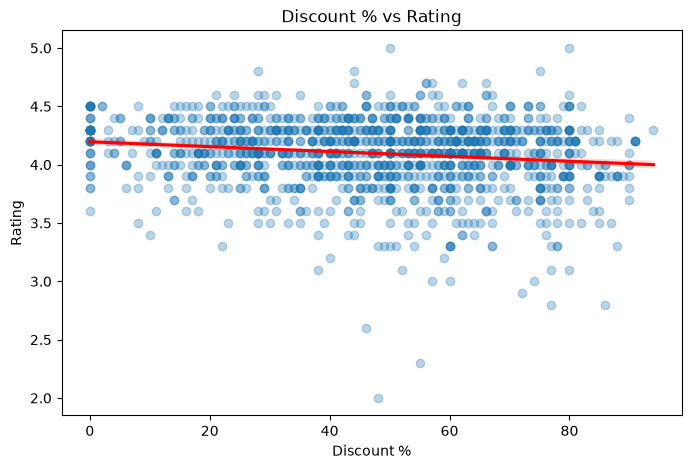

In [25]:
df[['discount_percentage', 'rating']].corr()

# scatter with regression line
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='discount_percentage', y='rating', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.xlabel('Discount %')
plt.ylabel('Rating')
plt.title('Discount % vs Rating')
plt.show()

In [26]:
df.groupby('category_main').agg(
    mean_discount=('discount_percentage', 'mean'),
    mean_rating=('rating', 'mean'),
    n=('rating', 'count')
).sort_values('mean_discount', ascending=False).round(2)

,mean_discount,mean_rating,n
category_main,,,
HomeImprovement,57.50,4.25,2
Computers&Accessories,53.92,4.16,451
Health&PersonalCare,53.00,4.00,1
Electronics,50.83,4.08,526
MusicalInstruments,46.00,3.90,2
Car&Motorbike,42.00,3.80,1
Home&Kitchen,40.17,4.04,447
OfficeProducts,12.35,4.31,31
Toys&Games,0.00,4.30,1


`n` - the count of products in each category</br>
#### Conclusion

The scatter plot and regression line reveal only a weak negative relationship between discount percentage and rating, with the line dipping modestly from ~4.2 to ~4.0 across the 0–90% discount range, against a backdrop of heavy scatter (ratings from 2–5 at nearly every discount level). Ratings are tightly clustered overall (mostly 3.9–4.3), leaving limited variance for discount to explain in the first place. Among categories with reliable sample sizes (n > 30), the pattern holds loosely — `Electronics` and `Computers&Accessories` combine the deepest average discounts (~51–54%) with the lowest average ratings (~4.08–4.16), while `OfficeProducts`, with a much smaller average discount (~12%), has the highest average rating (4.31). Overall, this suggests a mild association consistent with the hypothesis, a good basis for regression model.

### Model

In [27]:
df_model = pd.get_dummies(df, columns=['category_main'], drop_first=True)
df_model.head()

,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,category_code,category_main_Computers&Accessories,category_main_Electronics,category_main_Health&PersonalCare,category_main_Home&Kitchen,category_main_HomeImprovement,category_main_MusicalInstruments,category_main_OfficeProducts,category_main_Toys&Games
0,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64.0,4.2,24269.0,0,True,False,False,False,False,False,False,False
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43.0,4.0,43994.0,0,True,False,False,False,False,False,False,False
2,Sounce Fast Phone Charging Cable & Data Sync U...,199.0,1899.0,90.0,3.9,7928.0,0,True,False,False,False,False,False,False,False
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,329.0,699.0,53.0,4.2,94363.0,0,True,False,False,False,False,False,False,False
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,154.0,399.0,61.0,4.2,16905.0,0,True,False,False,False,False,False,False,False


In [28]:
feature_cols = ['discounted_price', 'actual_price', 'discount_percentage'] + \
               [c for c in df_model.columns if c.startswith('category_main_')]

X = df_model[feature_cols]
y = df_model['rating']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
reg = LinearRegression()
reg.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[-0. , 0. ,-0. ,...,-0.21, 0.15, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['discounted_price','actual_price','discount_percentage',..., 'category_main_MusicalInstruments','category_main_OfficeProducts', 'category_main_Toys&Games']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.201
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [31]:
y_pred = reg.predict(X_test)

In [32]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("R sq:", r2_score(y_test, y_pred))
print("RMSE:", rmse)

R sq: 0.10781838710734626
RMSE: 0.27014994773946077


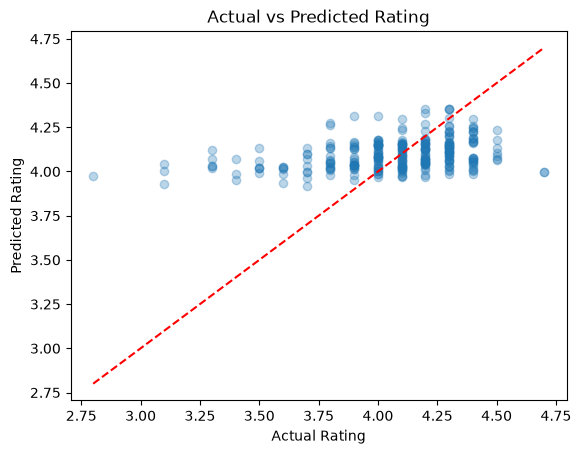

In [33]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Rating")

# reference line: perfect prediction would fall on this diagonal
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color='red', linestyle='--')

plt.show()

The actual-vs-predicted plot confirms the weak model fit numerically shown by R sq = 0.11 and RMSE = 0.27: predictions are tightly clustered around 4.0–4.25 regardless of the true rating, so the model systematically over-predicts low-rated products (true ratings of 2.75–3.5 are still predicted near 4.0) and under-predicts the highest-rated ones, rather than tracking the diagonal. This confirms that price, discount, and category alone explain only a small share of what drives a product's rating — supporting the conclusion that discounting and customer satisfaction are largely independent rather than discounting masking poor quality.


In [41]:
rf = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R sq:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R sq: 0.17012044352690292
RMSE: 0.26054682584208644


In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def rating_bucket(r):
    if r < 3.8:
        return 'Low'
    elif r < 4.3:
        return 'Medium'
    else:
        return 'High'

df['rating_class'] = df['rating'].apply(rating_bucket)

y_test_class = y_test.apply(rating_bucket)
y_pred_rf_class = pd.Series(y_pred_rf, index=y_test.index).apply(rating_bucket)

print("Accuracy:", accuracy_score(y_test_class, y_pred_rf_class))
print(confusion_matrix(y_test_class, y_pred_rf_class, labels=['Low', 'Medium', 'High']))
print(classification_report(y_test_class, y_pred_rf_class, zero_division=0))

Accuracy: 0.5938566552901023
[[  0  33   0]
 [  0 172   2]
 [  0  84   2]]
              precision    recall  f1-score   support

        High       0.50      0.02      0.04        86
         Low       0.00      0.00      0.00        33
      Medium       0.60      0.99      0.74       174

    accuracy                           0.59       293
   macro avg       0.37      0.34      0.26       293
weighted avg       0.50      0.59      0.45       293



### Random Forest Conclusion

The Random Forest model (R sq = 0.17, RMSE = 0.26) modestly outperforms the linear regression (R sq = 0.11), suggesting it captures some non-linear or category-specific patterns the linear model missed. However, the improvement is small, and the model still explains well under a fifth of the variance in rating — confirming that price, discount, and category are weak predictors of rating regardless of modeling approach. This convergence across two different algorithms strengthens the conclusion that discounting and customer satisfaction are largely independent, rather than heavy discounting masking weak product quality.